In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import importlib
import os
import modules.optics as op
import seaborn as sns

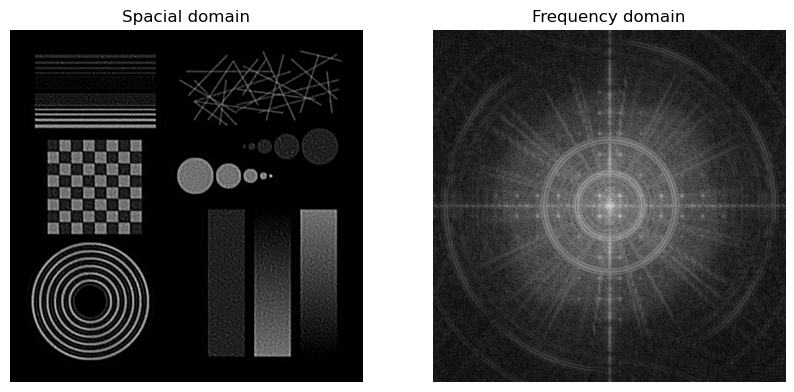

(512, 512)
0.0 1.0 (5, 2, 512, 512)
0.0 1.0 (512, 512)


In [25]:
# Load the clean reference image
folder_path = 'output_images/illumination_angles/5percent'

sim = np.stack([ski.io.imread(os.path.join(folder_path, 'filtered_angle0_sim.tif')),
                ski.io.imread(os.path.join(folder_path, 'filtered_angle1_sim.tif')),
                ski.io.imread(os.path.join(folder_path, 'filtered_angle2_sim.tif')),
                ski.io.imread(os.path.join(folder_path, 'filtered_angle3_sim.tif')),
                ski.io.imread(os.path.join(folder_path, 'filtered_angle4_sim.tif'))])

sim[sim < 0] = 0
sim_filtered = op.normalize(sim)
clean_sim = ski.io.imread('output_images/synthetic_grated_256_sim.tif')[:, :, 0]
sim_gt = ski.img_as_float(ski.color.rgb2gray(ski.io.imread('source_images\Synthetic512.png')))

op.display_fourier(sim_filtered[0][0])

print(np.shape(sim_gt))
clean_sim[clean_sim < 0] = 0
clean_sim = op.normalize(clean_sim)
metric = clean_sim

# sim_filtered = np.concatenate([sim_unfiltered]*4, axis=0)
print(np.min(sim_filtered), np.max(sim_filtered), np.shape(sim_filtered))

angleset = ['Perfect', 'Angle 1', 'Angle 2', 'Angle 3', 'Angle 4']
print(np.min(metric), np.max(metric), np.shape(metric))


,Angle,Noisy_PSNR,Noisy_SSIM,PSNR,SSIM
0,Perfect,28.784588,0.865101,28.886751,0.856868
1,Angle 1,28.343308,0.875028,28.873777,0.873485
2,Angle 2,28.246554,0.873064,28.789985,0.871146
3,Angle 3,28.301596,0.873345,28.782543,0.870771
4,Angle 4,28.779218,0.867436,28.952576,0.860127


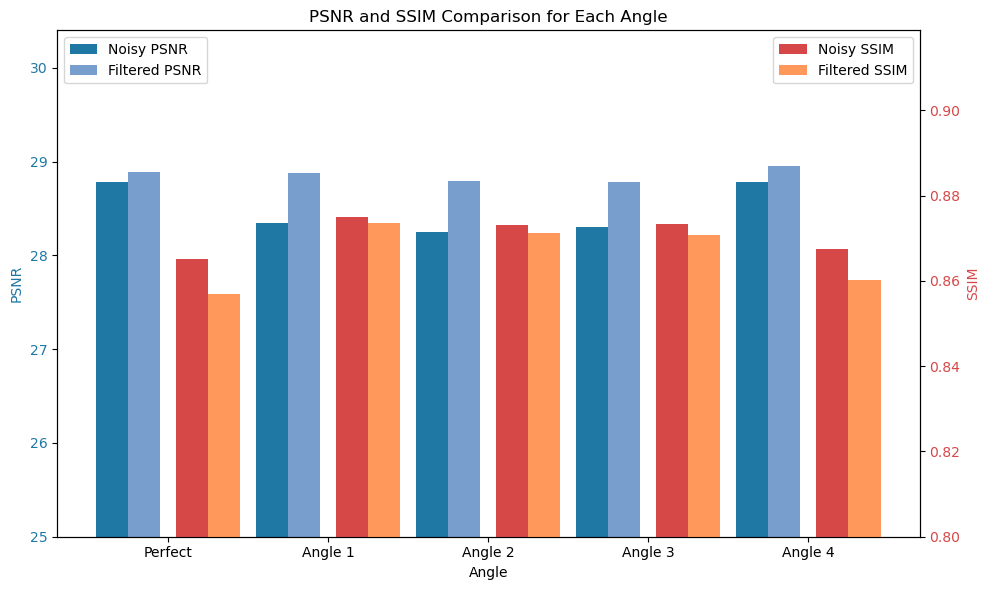

In [26]:

# Data storage
results = []

# Calculate PSNR and SSIM for each filter and each image
for filter_idx, filter_name in enumerate(angleset):
    # for img_idx in range(20):
    noisy_psnr_value = ski.metrics.peak_signal_noise_ratio(metric, sim_filtered[filter_idx][0])
    noisy_ssim_value = ski.metrics.structural_similarity(metric, sim_filtered[filter_idx][0], data_range=1)
    psnr_value = ski.metrics.peak_signal_noise_ratio(metric, sim_filtered[filter_idx][1])
    ssim_value = ski.metrics.structural_similarity(metric, sim_filtered[filter_idx][1], data_range=1)
    results.append([filter_name, noisy_psnr_value, noisy_ssim_value, psnr_value, ssim_value])

# Create a DataFrame to store the results
df = pd.DataFrame(results, columns=['Angle', 'Noisy_PSNR', 'Noisy_SSIM', 'PSNR', 'SSIM'])
display(df)

psnr_color = "#779ECC"  # Modern blue
ssim_color = "#FF985A"  # Modern orange
noisy_psnr_color = "#1f77a4"  # Darker blue for noisy threshold
noisy_ssim_color = "#d64748"  # Dark red for noisy threshold

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar positions
x = np.arange(len(angleset))
width = 0.2
offset = 0.25
# Plot PSNR on the left y-axis
ax1.bar(x - width/2 - offset, df['Noisy_PSNR'], width, label='Noisy PSNR', color=noisy_psnr_color)
ax1.bar(x + width/2 - offset, df['PSNR'], width, label='Filtered PSNR', color=psnr_color)
ax1.set_xlabel('Angle')
ax1.set_ylabel('PSNR', color=noisy_psnr_color)
ax1.set_ylim(ymin=25)
ax1.set_xticks(x)
ax1.set_xticklabels(angleset)
ax1.legend(loc='upper left')
ax1.tick_params(axis='y', labelcolor=noisy_psnr_color)

# Plot SSIM on the right y-axis
ax2 = ax1.twinx()
ax2.bar(x - width/2 + offset, df['Noisy_SSIM'], width, label='Noisy SSIM', color=noisy_ssim_color)
ax2.bar(x + width/2 + offset, df['SSIM'], width, label='Filtered SSIM', color=ssim_color)
ax2.set_ylabel('SSIM', color=noisy_ssim_color)
ax2.set_ylim(ymin=0.8)
ax2.legend(loc='upper right')
ax2.tick_params(axis='y', labelcolor=noisy_ssim_color)

plt.title('PSNR and SSIM Comparison for Each Angle')
plt.tight_layout()
plt.show()


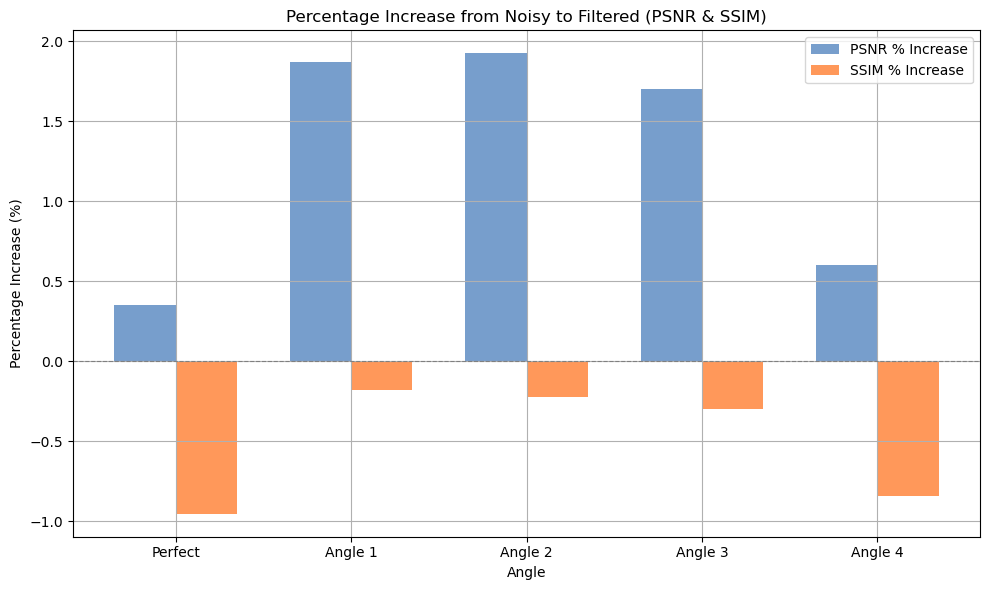

In [27]:
# Calculate percentage increases
psnr_increase = 100 * (df['PSNR'] - df['Noisy_PSNR']) / df['Noisy_PSNR']
ssim_increase = 100 * (df['SSIM'] - df['Noisy_SSIM']) / df['Noisy_SSIM']

# Bar positions
x = np.arange(len(angleset))
width = 0.35

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot percentage increases
ax.bar(x - width/2, psnr_increase, width, label='PSNR % Increase', color=psnr_color)
ax.bar(x + width/2, ssim_increase, width, label='SSIM % Increase', color=ssim_color)

# Formatting
ax.set_xlabel('Angle')
ax.set_ylabel('Percentage Increase (%)')
ax.set_title('Percentage Increase from Noisy to Filtered (PSNR & SSIM)')
ax.set_xticks(x)
ax.set_xticklabels(angleset)
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # Add a horizontal line at 0 for reference
plt.grid()
plt.tight_layout()
plt.show()


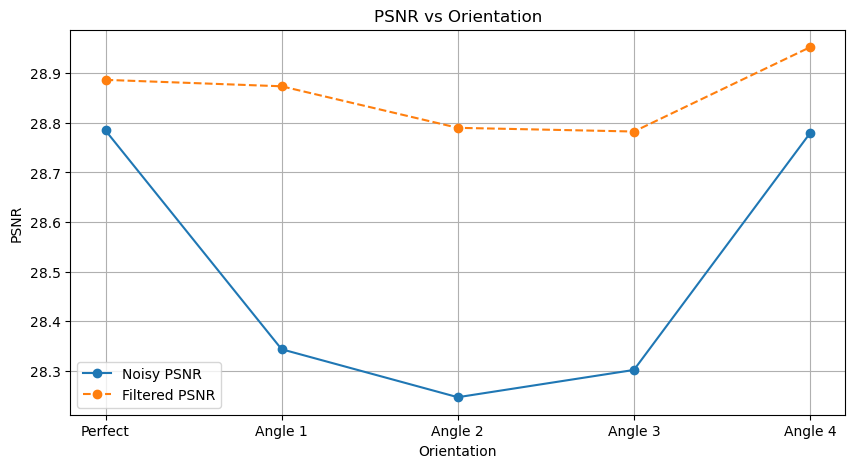

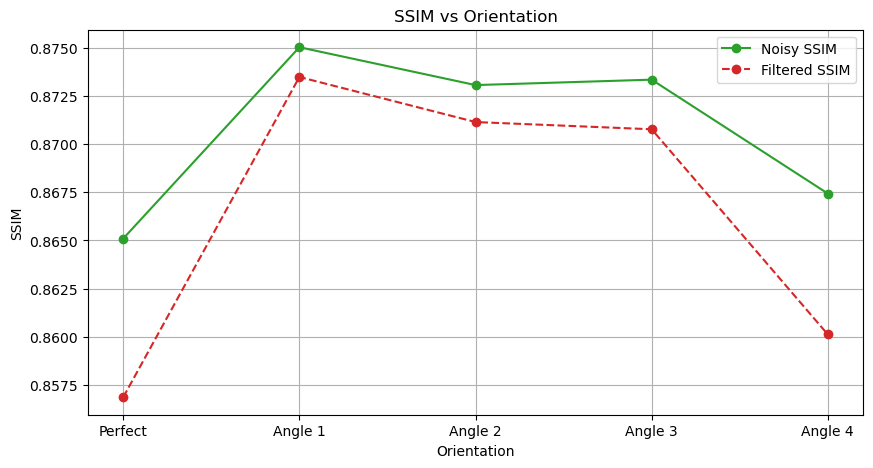

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(df['Angle'], df['Noisy_PSNR'], marker='o', label='Noisy PSNR', linestyle='-', color='tab:blue')
plt.plot(df['Angle'], df['PSNR'], marker='o', label='Filtered PSNR', linestyle='--', color='tab:orange')
plt.xlabel('Orientation')
plt.ylabel('PSNR')
plt.title('PSNR vs Orientation')
plt.legend()
plt.grid(True)
plt.show()

# Plotting SSIM
plt.figure(figsize=(10, 5))
plt.plot(df['Angle'], df['Noisy_SSIM'], marker='o', label='Noisy SSIM', linestyle='-', color='tab:green')
plt.plot(df['Angle'], df['SSIM'], marker='o', label='Filtered SSIM', linestyle='--', color='tab:red')
plt.xlabel('Orientation')
plt.ylabel('SSIM')
plt.title('SSIM vs Orientation')
plt.legend()
plt.grid(True)
plt.show()
